In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the Dataset
df = pd.read_csv("global_llm_benchmark_dataset_models.csv")
print(df.head())
print(df.shape)
print(df.columns.tolist())
print(df.info())

        model_name   provider release_date  context_window  \
0           GPT-4o     OpenAI   2024-05-13          128000   
1      GPT-4 Turbo     OpenAI   2023-11-06          128000   
2    GPT-3.5 Turbo     OpenAI   2023-03-01           16000   
3    Claude 3 Opus  Anthropic   2024-03-04          200000   
4  Claude 3 Sonnet  Anthropic   2024-03-04          200000   

   api_input_cost_per_1k_usd  api_output_cost_per_1k_usd  open_source  \
0                      0.005                       0.015        False   
1                      0.010                       0.030        False   
2                      0.001                       0.002        False   
3                      0.015                       0.075        False   
4                      0.003                       0.015        False   

   mmlu_score  gsm8k_score  humaneval_score  
0        88.7         92.0             90.2  
1        86.5         89.0             85.4  
2        70.0         57.1             48.1  
3   

In [8]:
# Converting release date to datetime 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

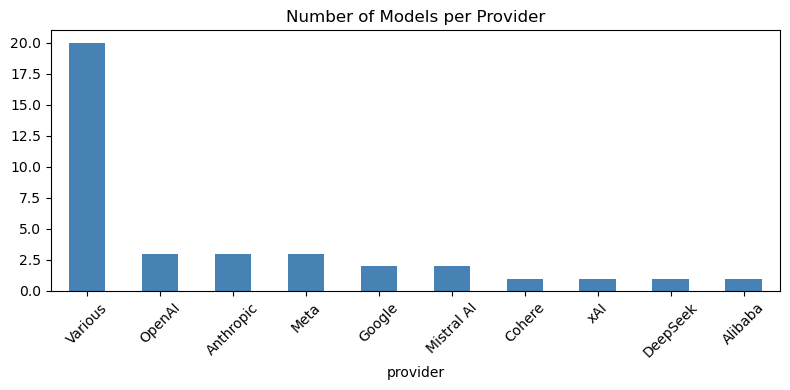

In [9]:
# 1. How many models per provider?
plt.figure(figsize=(8,4))
df['provider'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Number of Models per Provider")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


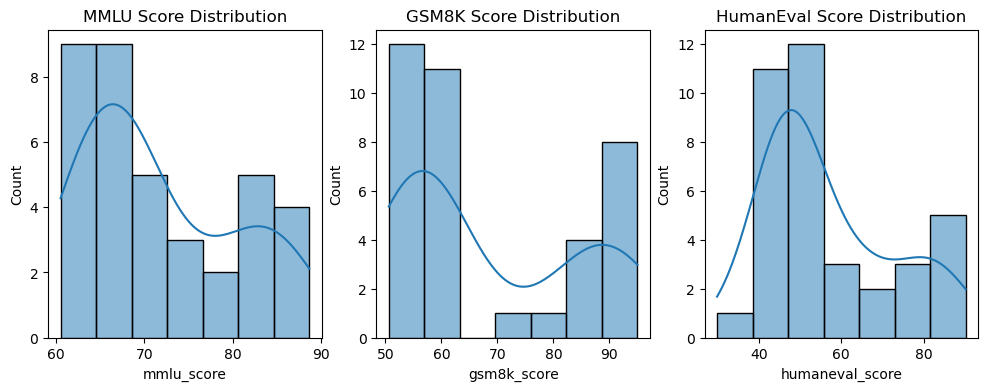

In [13]:
# 2 Univariate Distributions
# Histogram for scores
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['mmlu_score'], kde = True)
plt.title("MMLU Score Distribution")

plt.subplot(1,3,2)
sns.histplot(df['gsm8k_score'], kde = True)
plt.title("GSM8K Score Distribution")

plt.subplot(1,3,3)
sns.histplot(df['humaneval_score'], kde = True)
plt.title("HumanEval Score Distribution")
plt.show()

In [16]:
print(df[['mmlu_score', 'gsm8k_score', 'humaneval_score']].describe())
print("\nTop 5 best models by average score:")
df['avg_score'] = df[['mmlu_score','gsm8k_score','humaneval_score']].mean(axis=1)
print(df.sort_values('avg_score', ascending=False)[['model_name', 'provider', 'avg_score']].head(8))

       mmlu_score  gsm8k_score  humaneval_score
count   37.000000    37.000000        37.000000
mean    71.729730    68.372973        56.583784
std      8.619708    15.981129        15.517222
min     60.500000    50.600000        29.900000
25%     65.000000    55.400000        45.600000
50%     69.000000    60.200000        51.200000
75%     79.800000    86.500000        66.000000
max     88.700000    95.000000        90.200000

Top 5 best models by average score:
         model_name    provider  avg_score
0            GPT-4o      OpenAI  90.300000
3     Claude 3 Opus   Anthropic  88.900000
1       GPT-4 Turbo      OpenAI  86.966667
15      DeepSeek-V2    DeepSeek  85.533333
6    Gemini 1.5 Pro      Google  84.900000
4   Claude 3 Sonnet   Anthropic  84.266667
8       Llama 3 70B        Meta  84.233333
11    Mistral Large  Mistral AI  81.500000


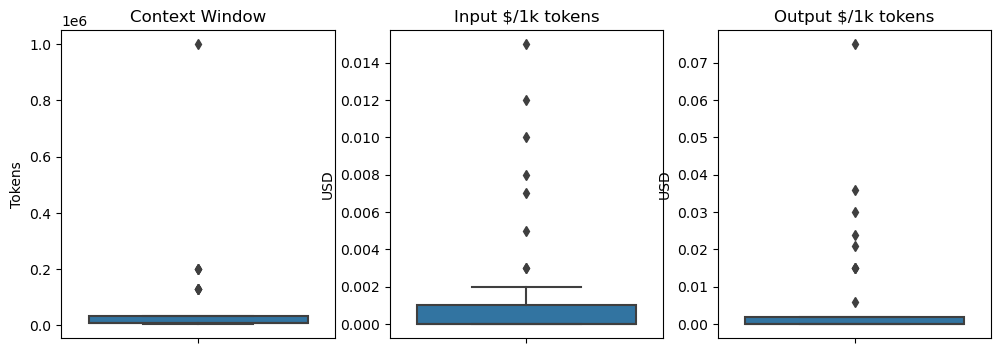

In [20]:
# Box plot for context window and costs
plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['context_window'])
plt.title("Context Window")
plt.ylabel('Tokens')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['api_input_cost_per_1k_usd'])
plt.title("Input $/1k tokens")
plt.ylabel('USD')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['api_output_cost_per_1k_usd'])
plt.title("Output $/1k tokens")
plt.ylabel('USD')
plt.show()

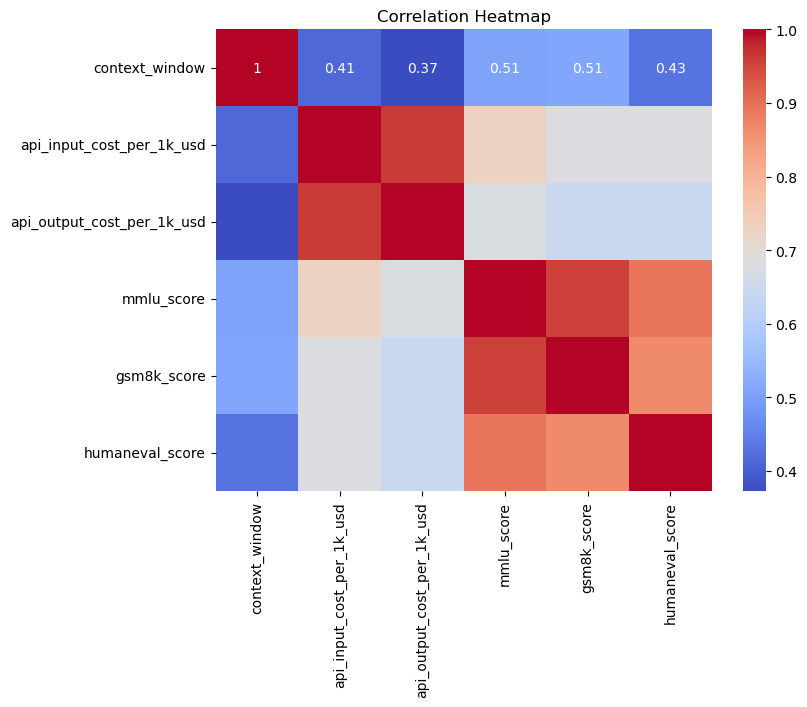

In [21]:
# Step 3 Relationships & Correlation
# Correlation Matrix
numeric_cols = ['context_window', 'api_input_cost_per_1k_usd', 'api_output_cost_per_1k_usd', 'mmlu_score', 'gsm8k_score', 'humaneval_score']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

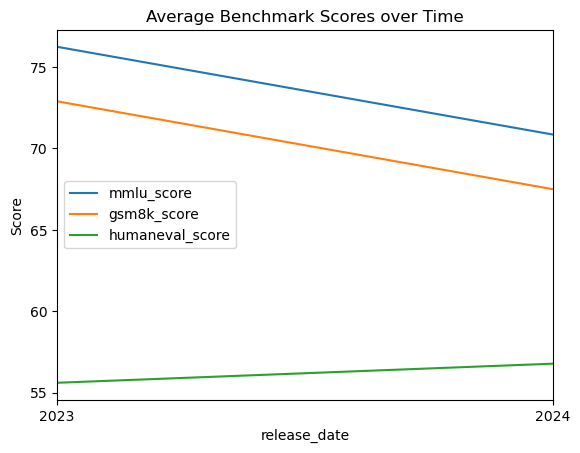

In [22]:
# Time Based Trends
df_time = df.set_index('release_date')
df_time.resample('Y').mean(numeric_only=True)[['mmlu_score', 'gsm8k_score', 'humaneval_score']].plot()
plt.title('Average Benchmark Scores over Time')
plt.ylabel('Score')
plt.show()

            mmlu_score  gsm8k_score  humaneval_score
provider                                            
Google       84.800000    92.200000        70.700000
DeepSeek     84.200000    90.100000        82.300000
OpenAI       81.733333    79.366667        74.566667
Anthropic    81.333333    89.100000        75.466667
Cohere       79.800000    88.000000        66.000000
Mistral AI   77.850000    85.100000        58.500000
Alibaba      77.300000    84.500000        53.000000
Meta         73.400000    72.666667        57.933333
xAI          73.000000    63.200000        63.000000
Various      65.250000    56.300000        47.350000


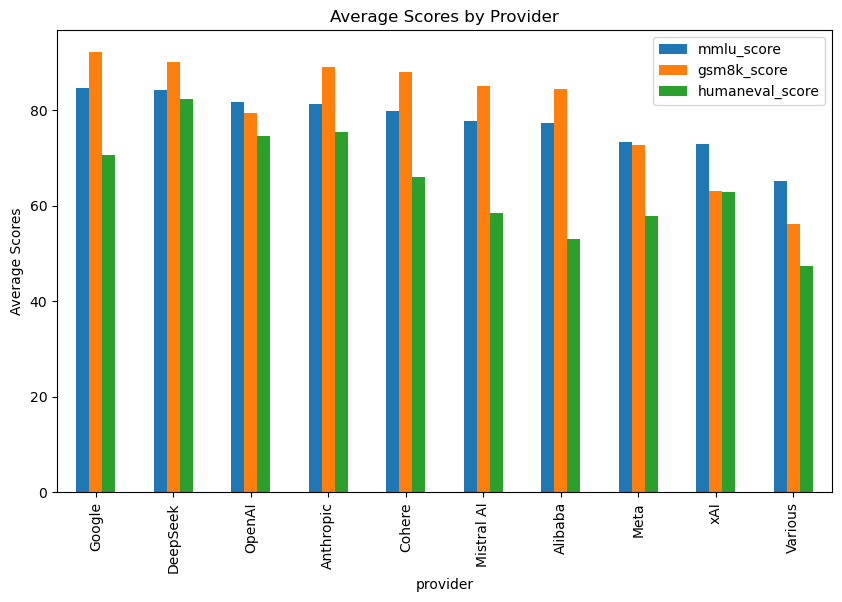

In [25]:
# Group Comparissons
# average scores by provider
provider_group = df.groupby('provider')[['mmlu_score', 'gsm8k_score', 'humaneval_score']].mean().sort_values('mmlu_score', ascending=False)
print(provider_group)
provider_group.plot(kind='bar', figsize=(10,6))
plt.title("Average Scores by Provider")
plt.ylabel("Average Scores")
plt.show()

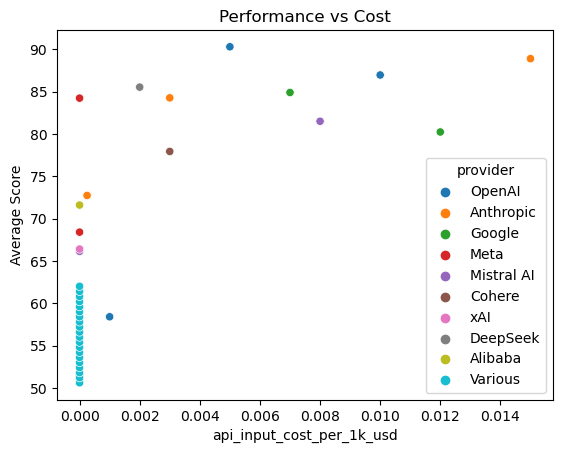

In [27]:
# Cost-Performance Trade off
df['Average Score'] = df[['mmlu_score', 'gsm8k_score', 'humaneval_score']].mean(axis=1)
sns.scatterplot(x='api_input_cost_per_1k_usd', y='Average Score', data=df, hue='provider')
plt.title('Performance vs Cost')
plt.show()